# Détection des zones de sous-desserte (Classification)

**Problématique** : Détecter les zones de sous-desserte ou fragiles — classification des relations présentant un risque stratégique.

**Objectif** : Prédire le `desserte_type` d'une relation ferroviaire à partir de ses caractéristiques.

## Imports & Configuration

In [15]:
!pip install numpy pandas matplotlib seaborn scikit-learn joblib


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, roc_auc_score,
    balanced_accuracy_score, matthews_corrcoef
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier

In [17]:
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
RANDOM_STATE = 42

## Chargement des données

**! Attention connecter api ici**

In [18]:
INPUT_FOLDER = "../../../data/output"

csv_files = glob.glob(os.path.join(INPUT_FOLDER, "*.csv"))
print(f"Fichiers trouvés : {[os.path.basename(f) for f in csv_files]}")

dfs = []
for filepath in csv_files:
    df_tmp = pd.read_csv(filepath)
    print(f"{os.path.basename(filepath)} : {len(df_tmp)} lignes")
    dfs.append(df_tmp)

df_raw = pd.concat(dfs, ignore_index=True)


print(f"\nDataset combiné : {df_raw.shape[0]} lignes et {df_raw.shape[1]} colonnes")
df_raw.head()

Fichiers trouvés : ['austria_etl.csv', 'germany_etl.csv', 'spain_etl.csv']
austria_etl.csv : 3683 lignes
germany_etl.csv : 876 lignes
spain_etl.csv : 680 lignes

Dataset combiné : 5239 lignes et 6 colonnes


,data_source,route_id,id_origin_city,id_destination_city,weekly_train,desserte_type
0,austria,1-80-j26-1,at:49:1349:0:10,at:43:4132:0:1,1,Sous-desservi
1,austria,1-MB4-j26-1,at:48:130:0:12,at:48:134:0:8,37,Desserte Normale
2,austria,1-MB4-j26-1,at:48:134:0:8,at:48:130:0:1,1,Sous-desservi
3,austria,1-MB4-j26-1,at:48:134:0:8,at:48:130:0:10,3,Sous-desservi
4,austria,1-MB4-j26-1,at:48:134:0:8,at:48:130:0:4,37,Desserte Normale


## Exploration des données

In [19]:
print("Types & valeurs manquantes")
print(df_raw.dtypes)
print("\nValeurs manquantes :")
print(df_raw.isnull().sum())

Types & valeurs manquantes
data_source            object
route_id               object
id_origin_city         object
id_destination_city    object
weekly_train            int64
desserte_type          object
dtype: object

Valeurs manquantes :
data_source            0
route_id               0
id_origin_city         0
id_destination_city    0
weekly_train           0
desserte_type          0
dtype: int64


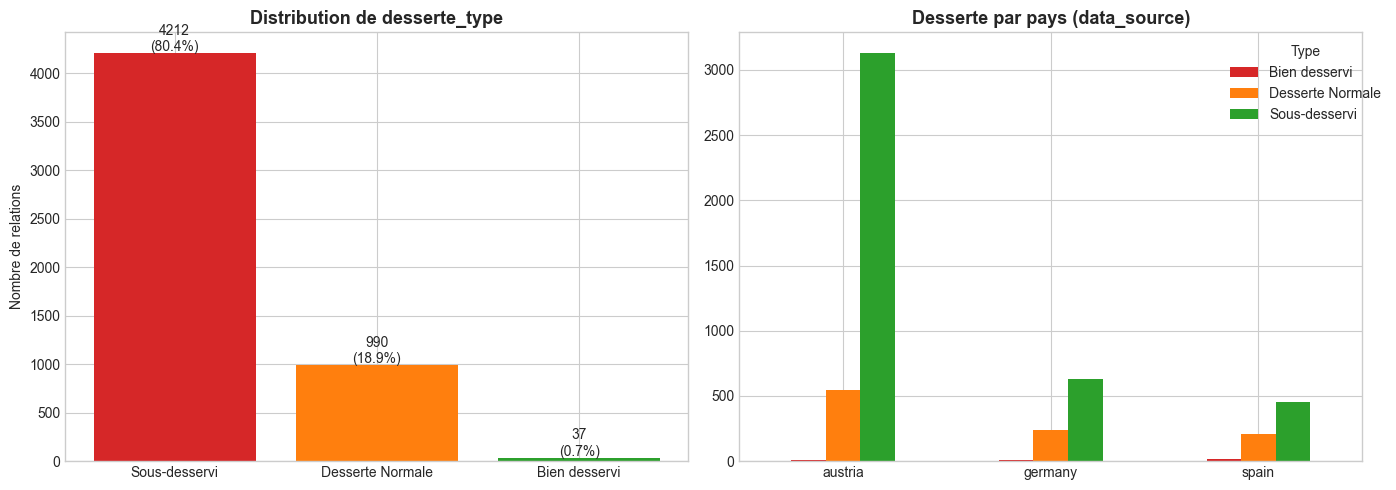

Déséquilibre de classes détecté stratégie class_weight='balanced' appliquée dans les modèles


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution de la target
counts = df_raw['desserte_type'].value_counts()
colors = ['#d62728', '#ff7f0e', '#2ca02c']
axes[0].bar(counts.index, counts.values, color=colors[:len(counts)])
axes[0].set_title('Distribution de desserte_type', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Nombre de relations')
for i, (idx, val) in enumerate(counts.items()):
    axes[0].text(i, val + 20, f'{val}\n({val/len(df_raw)*100:.1f}%)', ha='center', fontsize=10)

# Distribution par pays
pivot = df_raw.groupby(['data_source', 'desserte_type']).size().unstack(fill_value=0)
pivot.plot(kind='bar', ax=axes[1], color=colors[:pivot.shape[1]])
axes[1].set_title('Desserte par pays (data_source)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Type', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()
print("Déséquilibre de classes détecté stratégie class_weight='balanced' appliquée dans les modèles")

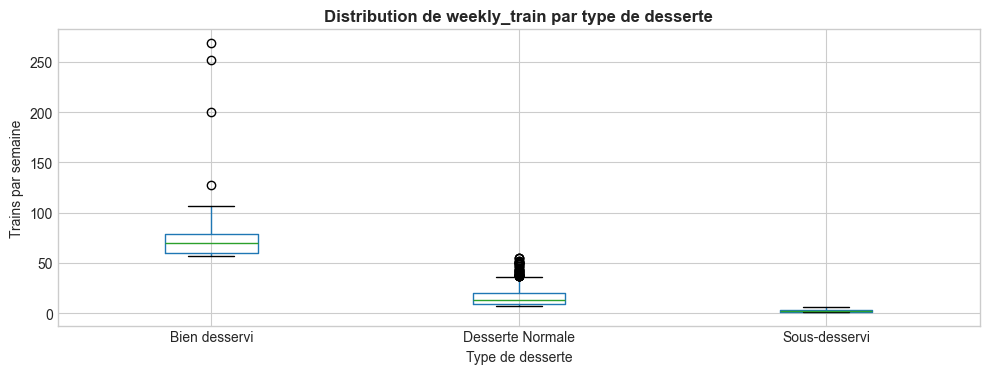

In [21]:
fig, ax = plt.subplots(figsize=(10, 4))
df_raw.boxplot(column='weekly_train', by='desserte_type', ax=ax)
ax.set_title('Distribution de weekly_train par type de desserte', fontsize=12, fontweight='bold')
ax.set_xlabel('Type de desserte')
ax.set_ylabel('Trains par semaine')
plt.suptitle('')
plt.tight_layout()
plt.show()

## Préparation des features

In [22]:
df = df_raw.copy()

FEATURES = ['data_source', 'route_id', 'id_origin_city', 'id_destination_city', 'weekly_train']
TARGET   = 'desserte_type'

# Encodage des variables catégorielles
le_source = LabelEncoder()
df['data_source_enc'] = le_source.fit_transform(df['data_source'].astype(str))

le_route = LabelEncoder()
df['route_id_enc'] = le_route.fit_transform(df['route_id'].astype(str))

le_origin = LabelEncoder()
df['id_origin_city_enc'] = le_origin.fit_transform(df['id_origin_city'].astype(str))

le_dest = LabelEncoder()
df['id_destination_city_enc'] = le_dest.fit_transform(df['id_destination_city'].astype(str))

# Encodage de la target
le_target = LabelEncoder()
df['target_enc'] = le_target.fit_transform(df[TARGET])
print("Classes :", dict(zip(le_target.classes_, le_target.transform(le_target.classes_))))

FEATURE_COLS = ['data_source_enc', 'route_id_enc', 'id_origin_city_enc',
                'id_destination_city_enc', 'weekly_train']

X = df[FEATURE_COLS].values
y = df['target_enc'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"\n Train : {X_train.shape[0]} | Test : {X_test.shape[0]}")

Classes : {'Bien desservi': np.int64(0), 'Desserte Normale': np.int64(1), 'Sous-desservi': np.int64(2)}

 Train : 4191 | Test : 1048


---
## Entraînement & Comparaison des modèles

Modèles testés :
- **Logistic Regression** : modèle linéaire, interprétable
- **Random Forest** : robuste, gère le déséquilibre, feature importance
- **Gradient Boosting** : souvent le plus performant sur données tabulaires

In [23]:
models = {
    'Logistic Regression'  : LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest'        : RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=RANDOM_STATE),
    'Gradient Boosting'    : GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE),
}

scaler  = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []

for name, model in models.items():
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    y_prob = model.predict_proba(X_test_sc) if hasattr(model, 'predict_proba') else None

    # Cross-validation F1 macro
    cv_f1 = cross_val_score(model, X_train_sc, y_train, cv=cv, scoring='f1_macro').mean()

    row = {
        'Modèle'              : name,
        'Accuracy'            : accuracy_score(y_test, y_pred),
        'Balanced Accuracy'   : balanced_accuracy_score(y_test, y_pred),
        'F1 Macro'            : f1_score(y_test, y_pred, average='macro'),
        'F1 Weighted'         : f1_score(y_test, y_pred, average='weighted'),
        'Precision Macro'     : precision_score(y_test, y_pred, average='macro'),
        'Recall Macro'        : recall_score(y_test, y_pred, average='macro'),
        'MCC'                 : matthews_corrcoef(y_test, y_pred),
        'CV F1 Macro (train)' : cv_f1,
    }
    if y_prob is not None:
        row['ROC-AUC (OvR)'] = roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro')
    else:
        row['ROC-AUC (OvR)'] = np.nan

    results.append(row)
    print(f"{name}")

df_results = pd.DataFrame(results).set_index('Modèle')
print("\n Entraînement terminé")

Logistic Regression
Random Forest
Gradient Boosting

 Entraînement terminé


## Tableau de métriques comparatif

In [24]:
pd.set_option('display.float_format', '{:.4f}'.format)
styled = df_results.style\
    .background_gradient(cmap='RdYlGn', subset=['Accuracy','Balanced Accuracy','F1 Macro','MCC','ROC-AUC (OvR)'])\
    .format('{:.4f}')\
    .set_caption('Comparaison des métriques')
styled

,Accuracy,Balanced Accuracy,F1 Macro,F1 Weighted,Precision Macro,Recall Macro,MCC,CV F1 Macro (train),ROC-AUC (OvR)
Modèle,,,,,,,,,
Logistic Regression,0.9876,0.9897,0.9133,0.9881,0.8640,0.9897,0.9619,0.9555,0.9997
Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.9937,1.0000
Gradient Boosting,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


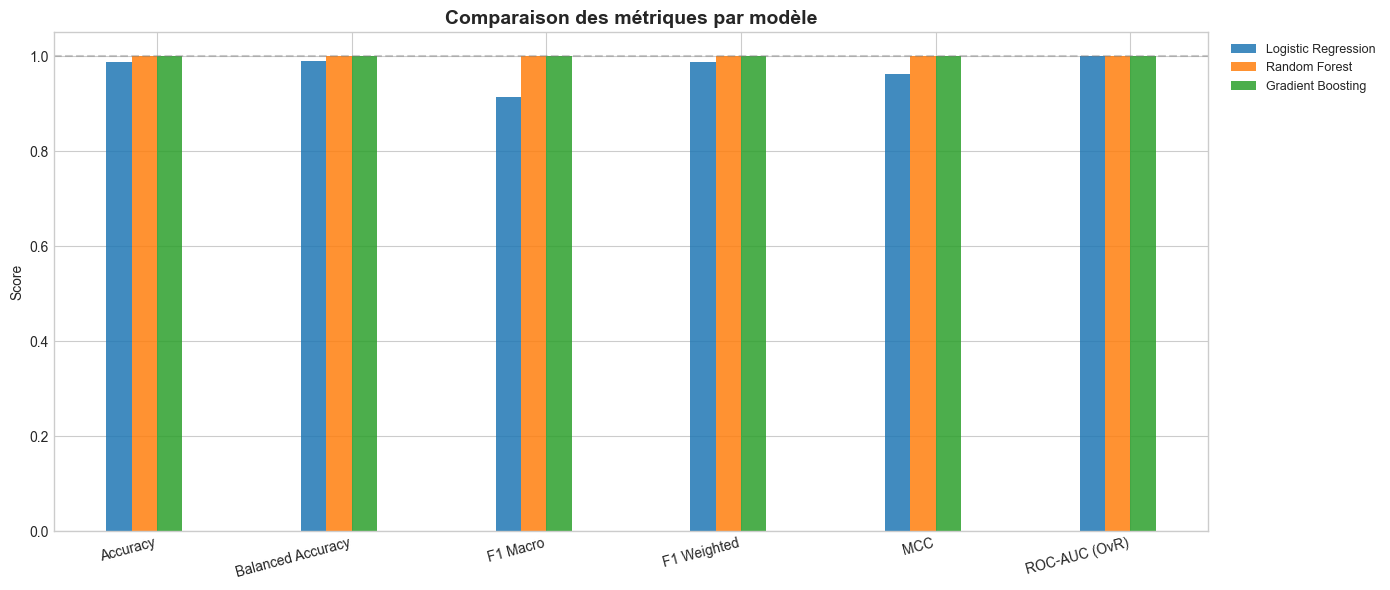

In [25]:
# Visualisation radar / bar chart des métriques clés
metrics_to_plot = ['Accuracy', 'Balanced Accuracy', 'F1 Macro', 'F1 Weighted', 'MCC', 'ROC-AUC (OvR)']
df_plot = df_results[metrics_to_plot].dropna(axis=1)

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(df_plot.columns))
width = 0.13

for i, (model_name, row) in enumerate(df_plot.iterrows()):
    offset = (i - len(df_plot)/2) * width
    bars = ax.bar(x + offset, row.values, width, label=model_name, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(df_plot.columns, rotation=15, ha='right')
ax.set_ylim(0, 1.05)
ax.set_title('Comparaison des métriques par modèle', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## Meilleur modèle Analyse détaillée

In [26]:
# Sélection automatique sur F1 Macro
best_model_name = df_results['F1 Macro'].idxmax()
best_model = models[best_model_name]
print(f"Meilleur modèle : {best_model_name}")
print(f"F1 Macro = {df_results.loc[best_model_name, 'F1 Macro']:.4f}")

Meilleur modèle : Random Forest
F1 Macro = 1.0000


Rapport de classification
                  precision    recall  f1-score   support

   Bien desservi       1.00      1.00      1.00         7
Desserte Normale       1.00      1.00      1.00       198
   Sous-desservi       1.00      1.00      1.00       843

        accuracy                           1.00      1048
       macro avg       1.00      1.00      1.00      1048
    weighted avg       1.00      1.00      1.00      1048



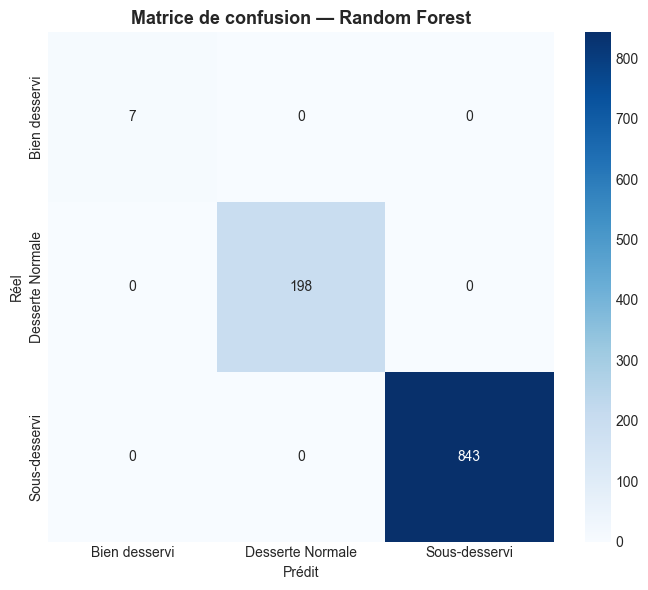

In [27]:
y_pred_best = best_model.predict(X_test_sc)
class_names = le_target.classes_

print("Rapport de classification")
print(classification_report(y_test, y_pred_best, target_names=class_names))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title(f'Matrice de confusion — {best_model_name}', fontsize=13, fontweight='bold')
ax.set_ylabel('Réel')
ax.set_xlabel('Prédit')
plt.tight_layout()
plt.show()

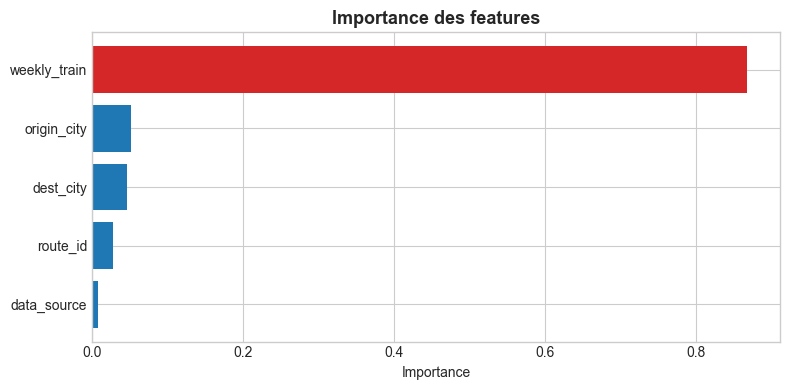

In [28]:
# Feature importance (si disponible)
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feat_names  = ['data_source', 'route_id', 'origin_city', 'dest_city', 'weekly_train']
    fi_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})\
              .sort_values('Importance', ascending=True)

    fig, ax = plt.subplots(figsize=(8, 4))
    colors_bar = ['#d62728' if i == fi_df['Importance'].idxmax() else '#1f77b4'
                  for i in fi_df.index]
    ax.barh(fi_df['Feature'], fi_df['Importance'], color=colors_bar)
    ax.set_title('Importance des features', fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()
elif hasattr(best_model, 'coef_'):
    print("Logistic Regression — coefficients par classe :")
    feat_names = ['data_source', 'route_id', 'origin_city', 'dest_city', 'weekly_train']
    for i, cls in enumerate(class_names):
        print(f"  {cls}: {dict(zip(feat_names, best_model.coef_[i].round(3)))}")

## Export des résultats